# Event Splitting Training (Unified Config Pipeline)

This notebook trains/evaluates/exports the event-splitting model with the unified `training_pipeline`.

## 1) Environment Setup

In [1]:
from pathlib import Path

from pioneerml.evaluation.plots.loss import LossCurvesPlot
from pioneerml.integration.zenml import load_step_output
from pioneerml.integration.zenml import utils as zenml_utils
from pioneerml.pipeline.pipelines.training import training_pipeline

PROJECT_ROOT = zenml_utils.find_project_root()
zenml_utils.setup_zenml_for_notebook(root_path=PROJECT_ROOT, use_in_memory=True)

Using ZenML repository root: /workspace
Ensure this is the top-level of your repo (.zen must live here).


## 2) Build Aligned Inputs

Event-splitting training needs the main parquet plus aligned prediction parquet from:
- group classifier (`group_classifier`)
- group splitter (`group_splitter`)
- endpoint regressor (`endpoint_regressor`)

In [2]:
data_dir = Path(PROJECT_ROOT) / "data"
main_paths = sorted(data_dir.glob("ml_output_*.parquet"))

# Optional: use fewer files
main_paths = main_paths[:1]

group_classifier_dir = data_dir / "group_classifier"
group_splitter_dir = data_dir / "group_splitter"
endpoint_dir = data_dir / "endpoint_regressor"

def _pick_pred(pred_dir: Path, main_path: Path) -> Path | None:
    primary = pred_dir / f"{main_path.stem}_preds.parquet"
    if primary.exists():
        return primary
    latest = pred_dir / f"{main_path.stem}_preds_latest.parquet"
    if latest.exists():
        return latest
    return None

paired = []
missing = []
for mp in main_paths:
    gc = _pick_pred(group_classifier_dir, mp)
    gs = _pick_pred(group_splitter_dir, mp)
    ep = _pick_pred(endpoint_dir, mp)
    if gc is not None and gs is not None and ep is not None:
        paired.append((str(mp.resolve()), str(gc.resolve()), str(gs.resolve()), str(ep.resolve())))
    else:
        missing.append(mp.name)

if not paired:
    raise RuntimeError(
        "No fully aligned event-splitting input sets found. Run upstream inference first."
    )
if missing:
    print(f"Warning: skipping {len(missing)} shard(s) with missing prerequisites: {missing[:5]}")

parquet_paths = [p[0] for p in paired]
group_probs_parquet_paths = [p[1] for p in paired]
group_splitter_parquet_paths = [p[2] for p in paired]
endpoint_parquet_paths = [p[3] for p in paired]

print(f"Using {len(parquet_paths)} shard(s).")

Using 1 shard(s).


## 3) Reusable Config Helpers

In [3]:
from pioneerml.plugin.runtime import ensure_plugins_loaded
ensure_plugins_loaded()

from pioneerml_base_plugin.event_splitter.pipeline import load_config
from pioneerml_base_plugin.utils.config_loader import with_export_output, with_loader_sources


## 4) Build Step Config Blocks

HPO search-space keys are routed automatically:
- architecture keys (`hidden`, `heads`, `layers`, `dropout`) -> `architecture.config`
- module keys (`lr`, `weight_decay`) -> `module.config`
- runtime keys (`batch_size`) -> loader defaults.

In [4]:
pipeline_config = load_config()["training"]
pipeline_config = with_loader_sources(
    pipeline_config,
    main_sources=parquet_paths,
    optional_sources_by_name={"group_probs": group_probs_parquet_paths, "group_splitter": group_splitter_parquet_paths, "endpoint": endpoint_parquet_paths},
)
pipeline_config = with_export_output(
    pipeline_config,
    export_dir=str(Path(PROJECT_ROOT) / "trained_models" / "event_splitter"),
    filename_prefix="event_splitter",
)


## 5) Assemble `pipeline_config` and Run

In [5]:
run = training_pipeline.with_options(enable_cache=False)(
    pipeline_config=pipeline_config,
)


Initiating a new run for the pipeline: training_pipeline.
Caching is disabled by default for training_pipeline.
Using user: default
Using stack: default
  deployer: default
  artifact_store: default
  orchestrator: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step tune_model has started.


[I 2026-03-26 01:34:25,175] A new study created in RDB with name: event_splitter_hpo


[tune_model] GPU available: True (cuda), used: True
[tune_model] TPU available: False, using: 0 TPU cores
[tune_model] You are using a CUDA device ('NVIDIA GeForce RTX 5070') that has Tensor Cores. To properly utilize them, you should set torch.set_float32_matmul_precision('medium' | 'high') which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
[tune_model] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ EventSplitter     │  812 K │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 812 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 812 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 60                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Step tune_model has finished in 28.584s.
Step train_model has started.
[train_model] GPU available: True (cuda), used: True
[train_model] TPU available: False, using: 0 TPU cores
[train_model] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ EventSplitter     │  3.3 M │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 3.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.3 M                                                                                                
Total estimated model params size (MB): 13                                                                         
Modules in train mode: 76                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[train_model] No materializer is registered for type <class 'pioneerml.integration.pytorch.modules.graph_lightning_module.GraphLightningModule'>, so the default Pickle materializer was used. Pickle is not production ready and should only be used for prototyping as the artifacts cannot be loaded when running with a different Python version. Please consider implementing a custom materializer for type <class 'pioneerml.integration.pytorch.modules.graph_lightning_module.GraphLightningModule'> according to the instructions at https://docs.zenml.io/concepts/artifacts/materializers
Step train_model has finished in 42.564s.
Step evaluate_model has started.
Step evaluate_model has finished in 11.612s.
Step export_model has started.
Step export_model has finished in 1.693s.
Pipeline run has finished in 1m28s.


## 6) Load Step Outputs and Inspect Results

hpo_params: {'study_name': 'event_splitter_hpo', 'storage': 'sqlite:////workspace/.optuna/event_splitter_hpo.db', 'best_params': {'batch_size_exp': 3, 'lr': 0.00020677577447477646, 'weight_decay': 1.197103434031098e-05, 'hidden': 256, 'heads': 2, 'layers': 4, 'dropout': 0.281237101047161, 'batch_size': 8}}
metrics (summary): {'loss': 0.25763991308263867, 'accuracy': 0.9134727731698521, 'exact_match': 0.9134727731698521, 'confusion': [{'tn': 0.43252650558961414, 'fp': 0.04758600793364587, 'fn': 0.03894121889650198, 'tp': 0.480946267580238}], 'threshold': 0.5, 'train_loss_history_total_points': 7, 'val_loss_history_total_points': 8}
export: {'torchscript_path': '/workspace/trained_models/event_splitter/event_splitter_20260326_013550_torchscript.pt', 'metadata_path': '/workspace/trained_models/event_splitter/event_splitter_20260326_013550_meta.json', 'export_type': 'script', 'exporter_type': 'torchscript'}


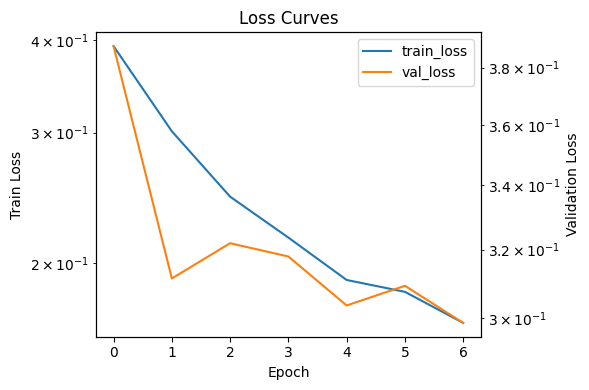

In [6]:
hpo_output = load_step_output(run, "tune_model")
train_output = load_step_output(run, "train_model")
evaluate_output = load_step_output(run, "evaluate_model")
export_output = load_step_output(run, "export_model")

hpo_params = hpo_output.get("hpo_params") if isinstance(hpo_output, dict) else hpo_output
trained_module = train_output.get("module") if isinstance(train_output, dict) else train_output
metrics = evaluate_output.get("metrics") if isinstance(evaluate_output, dict) else evaluate_output

summary = dict(metrics or {})
summary.pop("train_loss_history", None)
summary.pop("val_loss_history", None)

print("hpo_params:", hpo_params)
print("metrics (summary):", summary)
print("export:", export_output)

if trained_module is None:
    raise RuntimeError("No trained module loaded from pipeline run.")

LossCurvesPlot().render(
    trained_module,
    val_accuracy=(metrics.get("accuracy") if isinstance(metrics, dict) else None),
    show=True,
)